[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Simulating Circular Chase...


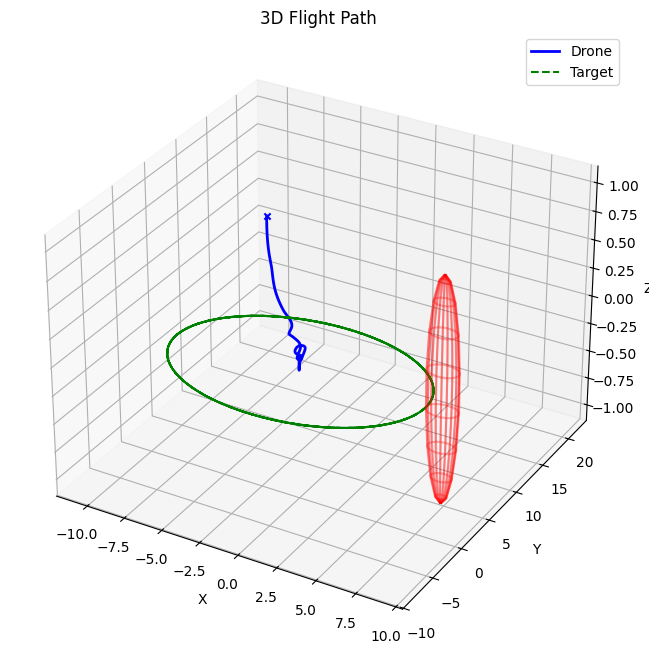

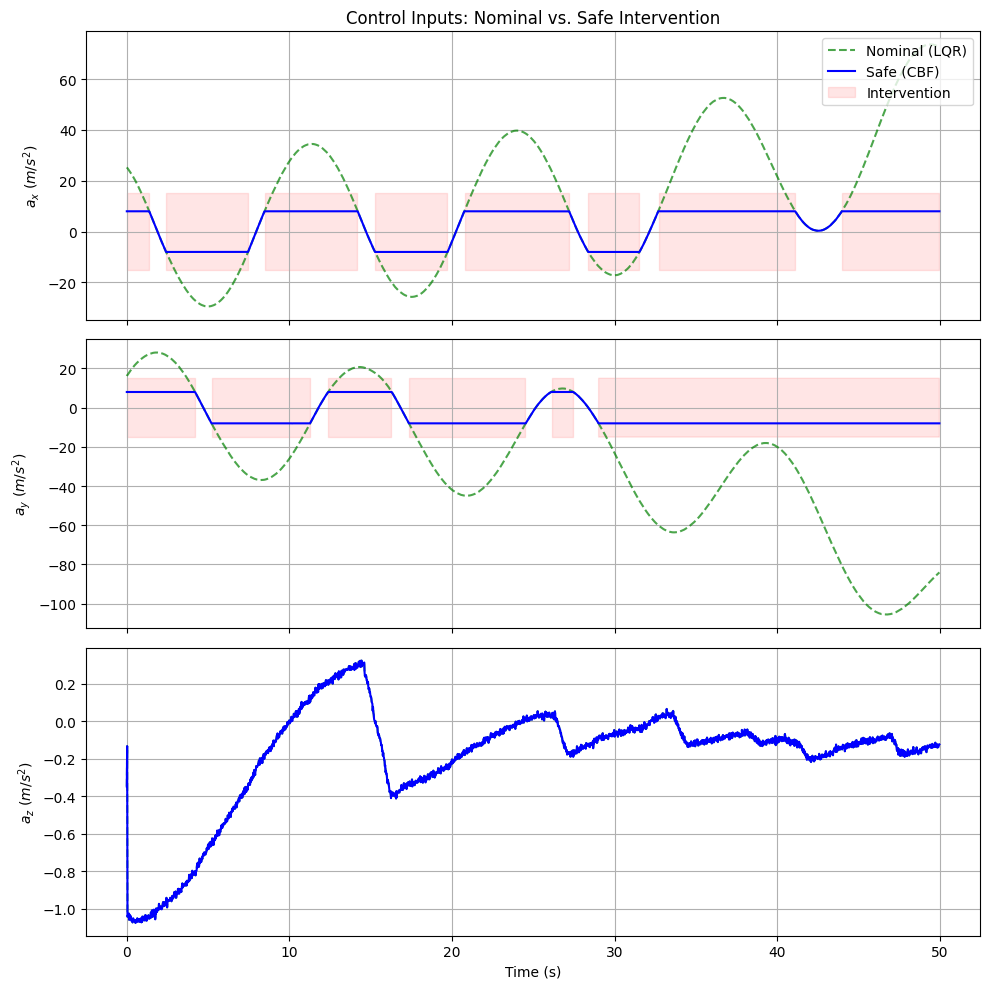

In [9]:
import numpy as np
import pybullet as p
from gym_pybullet_drones.envs.CtrlAviary import CtrlAviary
from gym_pybullet_drones.control.DSLPIDControl import DSLPIDControl
from gym_pybullet_drones.utils.enums import DroneModel, Physics
import matplotlib.pyplot as plt

# Import your existing modules
import scenarios
from guidance import NominalGuidance
from safety_filter import SafetyFilter

# --- PLOTTING FUNCTIONS ---

def plot_3d_trajectory(drone_path, target_path, obstacles):
    """Plots the spatial 3D path of the drone."""
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    path = np.array(drone_path)
    t_path = np.array(target_path)

    # Trajectories
    ax.plot(path[:, 0], path[:, 1], path[:, 2], label='Drone', color='b', linewidth=2)
    ax.plot(t_path[:, 0], t_path[:, 1], t_path[:, 2], label='Target', color='g', linestyle='--')
    
    # Start/End markers
    ax.scatter(path[0,0], path[0,1], path[0,2], c='b', marker='o')
    ax.scatter(path[-1,0], path[-1,1], path[-1,2], c='b', marker='x')

    # Obstacles
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    for obs in obstacles:
        x = obs.center[0] + obs.radius * np.cos(u) * np.sin(v)
        y = obs.center[1] + obs.radius * np.sin(u) * np.sin(v)
        z = obs.center[2] + obs.radius * np.cos(v)
        ax.plot_wireframe(x, y, z, color='r', alpha=0.3)

    ax.set_title("3D Flight Path")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.legend()
    plt.show()

def plot_control_inputs(u_nom_hist, u_safe_hist, time_hist):
    """
    Plots the Nominal vs Safe control inputs (Acceleration) over time.
    Shows exactly when the Safety Filter intervened.
    """
    u_nom = np.array(u_nom_hist)
    u_safe = np.array(u_safe_hist)
    t = np.array(time_hist)
    
    fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    
    labels = ['$a_x$', '$a_y$', '$a_z$']
    
    for i in range(3):
        # Plot Nominal (Desired)
        axs[i].plot(t, u_nom[:, i], 'g--', label='Nominal (LQR)', alpha=0.7)
        # Plot Safe (Actual)
        axs[i].plot(t, u_safe[:, i], 'b-', label='Safe (CBF)')
        
        axs[i].set_ylabel(f"{labels[i]} ($m/s^2$)")
        axs[i].grid(True)
        
        # Highlight intervention areas (where difference is large)
        diff = np.abs(u_nom[:, i] - u_safe[:, i])
        mask = diff > 0.1 # Threshold for "Active Intervention"
        if np.any(mask):
            axs[i].fill_between(t, -15, 15, where=mask, color='red', alpha=0.1, label='Intervention')

    axs[0].legend(loc='upper right')
    axs[0].set_title("Control Inputs: Nominal vs. Safe Intervention")
    axs[2].set_xlabel("Time (s)")
    
    plt.tight_layout()
    plt.show()

# --- MAIN SIMULATION ---

def run_pybullet_sim(scenario_name="chase", gui=False):
    if scenario_name not in scenarios.SCENARIOS:
        print("Scenario not found."); return
    mission = scenarios.SCENARIOS[scenario_name]()

    env = CtrlAviary(drone_model=DroneModel.CF2X, num_drones=1, neighbourhood_radius=10, physics=Physics.PYB, gui=gui)
    
    # Init
    initial_pos = mission.start_state.pos.reshape(1, 3)
    initial_rpy = np.array([[0., 0., 0.]])
    obs, _ = env.reset(seed=42)
    p.resetBasePositionAndOrientation(env.DRONE_IDS[0], initial_pos[0], p.getQuaternionFromEuler(initial_rpy[0]))

    ctrl = DSLPIDControl(drone_model=DroneModel.CF2X)
    guidance = NominalGuidance()
    safety_filter = SafetyFilter(u_max=8.0)

    # Sync Obstacles (Collision shapes)
    obs_body_ids = []
    for o in mission.obstacles:
        col = p.createCollisionShape(p.GEOM_SPHERE, radius=o.radius)
        # Only create visual if GUI is on
        vis = p.createVisualShape(p.GEOM_SPHERE, radius=o.radius, rgbaColor=[1,0,0,0.6]) if gui else -1
        bid = p.createMultiBody(0, col, vis, basePosition=o.center)
        obs_body_ids.append(bid)

    # Logging
    drone_path_hist = []
    target_path_hist = []
    u_nom_hist = []  # Store Nominal Inputs
    u_safe_hist = [] # Store Safe Inputs
    time_hist = []

    PYB_FREQ = 240
    CTRL_FREQ = 48
    total_steps = int(mission.duration * CTRL_FREQ)
    
    print(f"Simulating {mission.name}...")

    try:
        for i in range(total_steps):
            t = i / CTRL_FREQ
            
            # 1. State & Update
            state_vec = obs[0]
            curr_pos = state_vec[0:3]; curr_vel = state_vec[10:13]
            target_pos, target_vel = mission.target.update(t)
            
            # Update Obstacles
            for idx, o in enumerate(mission.obstacles):
                if np.linalg.norm(o.velocity) > 0:
                    o.center += o.velocity * (1/CTRL_FREQ)
                    if abs(o.center[1]) > 4.0: o.velocity[1] *= -1
                    p.resetBasePositionAndOrientation(obs_body_ids[idx], o.center, [0,0,0,1])

            # 2. Control Logic
            u_nom = guidance.compute_u_nom(curr_pos, curr_vel, target_pos, target_vel)
            u_safe = safety_filter.filter(u_nom, curr_pos, curr_vel, mission.obstacles)
            
            # 3. Store Data
            drone_path_hist.append(curr_pos.copy())
            target_path_hist.append(target_pos.copy())
            u_nom_hist.append(u_nom.copy())
            u_safe_hist.append(u_safe.copy())
            time_hist.append(t)

            # 4. Low Level Control
            dt_ctrl = 1/CTRL_FREQ
            target_pos_next = curr_pos + curr_vel * dt_ctrl + 0.5 * u_safe * dt_ctrl**2
            target_vel_next = curr_vel + u_safe * dt_ctrl
            
            rpm, _, _ = ctrl.computeControlFromState(
                control_timestep=dt_ctrl,
                state=state_vec,
                target_pos=target_pos_next,
                target_vel=target_vel_next,
                target_rpy=np.zeros(3),
                target_rpy_rates=np.zeros(3)
            )
            
            obs, _, _, _, _ = env.step(np.array([rpm]))
            
            if np.linalg.norm(curr_pos - target_pos) < 0.5:
                print(f"Target Reached at T={t:.2f}s")
                break

    except Exception as e:
        print(f"Error: {e}")
    finally:
        env.close()
        # Plot both graphs
        plot_3d_trajectory(drone_path_hist, target_path_hist, mission.obstacles)
        plot_control_inputs(u_nom_hist, u_safe_hist, time_hist)

if __name__ == "__main__":
    run_pybullet_sim("chase", gui=False)